<a href="https://colab.research.google.com/github/abhishekanand04/Intro-to-ML-and-NN/blob/machinelearning/Linear_Regression_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
class LinearRegression() :
  def __init__(self, learning_rate=0.01, iterations=5):
    self.learning_rate = learning_rate
    self.iterations = iterations
  def predict(self, X):
     return np.dot(X, self.W)+self.b

  def r2_score(self, y_hat, y):

    ss_res = np.sum((y-y_hat)**2)
    ss_tot = np.sum((y- y.mean())**2)
    score = (1- ss_res/ss_tot)
    return score

  def update_weights(self):
    Y_pred = self.predict( self.X )
    # calculate gradients
    dW = - (2*(self.X.T ).dot(self.Y - Y_pred))/self.m
    db = - 2*np.sum(self.Y - Y_pred)/self.m
    # print(self.X.shape, (self.Y-Y_pred).shape, dW.shape)
    # update weights
    self.W = self.W - self.learning_rate * dW
    self.b = self.b - self.learning_rate * db
    return self


  def fit(self, X, Y):
    # no_of_training_examples, no_of_features
    self.m, self.d = X.shape
    # weight initialization
    self.W = np.zeros(self.d)
    self.b = 0
    self.X = X
    self.Y = Y
    self.error_list=[]
    # gradient descent learning
    for i in range(self.iterations):
      Y_pred=X.dot(self.W)+self.b
      self.update_weights()
      error=np.square(np.subtract(Y,Y_pred)).mean()
      self.error_list.append(error)
    return self


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# !gdown 1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh

!gdown 1Uf8npawLbGPDBu9HBfNcvzhf_PdL9RhX

Downloading...
From: https://drive.google.com/uc?id=1Uf8npawLbGPDBu9HBfNcvzhf_PdL9RhX
To: /content/cars24-car-price-clean-new.csv
100% 6.57M/6.57M [00:00<00:00, 23.7MB/s]


In [ ]:
df = pd.read_csv('cars24-car-price-clean-new.csv')
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


In [ ]:
# define X and y
X = df.drop('selling_price', axis=1)
y = df["selling_price"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
lr = LinearRegression(iterations=100)
lr.fit(X_train, y_train)

In [ ]:
X_test

,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
3386,0.035608,-1.047869,0.212701,0.146493,1.426990,-0.433854,-1.003928,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
11664,-0.600193,1.009057,-0.533600,-0.315521,-1.075704,-0.639625,-0.493817,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
7327,-0.196436,-1.038562,2.467028,1.706347,-1.388540,0.724475,3.010306,1.248892,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,-2.249703,2.354446
17993,-0.621850,-0.838454,0.039142,0.504173,-0.762867,-0.246579,0.144345,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
19419,0.034873,-0.349818,-0.535528,-0.255200,-0.137194,-0.177218,-0.586183,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5241,0.770414,0.441308,-0.537456,-0.335628,-0.450030,-0.433854,-0.013096,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,-2.016868,0.444503,-0.424728
3172,0.388412,-0.791917,-1.310754,-1.365552,2.052663,-0.433854,-1.230644,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,-2.249703,-0.424728
18409,-0.757209,0.515767,0.042999,0.234070,-1.075704,-0.240799,0.165338,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,-2.016868,0.444503,-0.424728
4699,0.054945,0.320312,-0.539385,-0.813727,-0.137194,-0.433854,-0.726831,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


In [ ]:
lr.predict(X_test)

array([-0.83294987, -0.29658151,  2.45589861, ...,  0.64007471,
       -0.56647691,  0.08585621])

In [ ]:
y_hat_train = lr.predict(X_train)
lr.r2_score(y_hat_train, y_train)

np.float64(0.912359951740886)

In [ ]:
y_hat_test = lr.predict(X_test)
lr.r2_score(y_hat_test, y_test)

np.float64(0.9069471656845405)

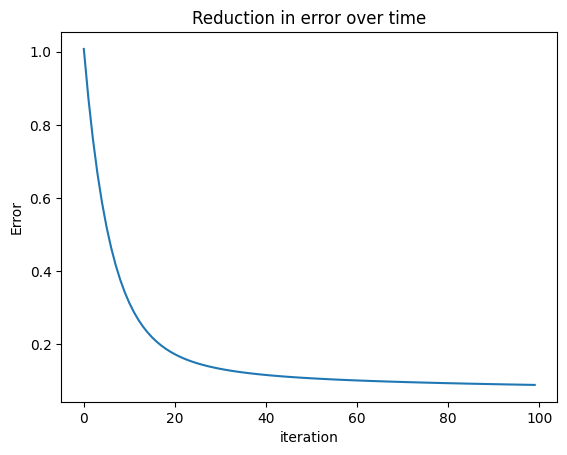

In [ ]:
%matplotlib inline
fig = plt.figure()
plt.plot(lr.error_list)
plt.title("Reduction in error over time")
plt.xlabel("iteration")
plt.ylabel("Error")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!gdown 1tWCalxQ6gGXD6sRTskh9XTjAgFH0xcNF

!gdown 1Fp6e6vf_YID8qwCNHWSbvPH5-R3HQB5N

!gdown 14q4g4K3DjIi7v8Omej9za9EmOpUeLIEH

!gdown 1TSGIJi5vcXYd398KaJpn7RXvckmttYIt

Downloading...
From: https://drive.google.com/uc?id=1tWCalxQ6gGXD6sRTskh9XTjAgFH0xcNF
To: /content/cars24_x_train.pkl
100% 1.78M/1.78M [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Fp6e6vf_YID8qwCNHWSbvPH5-R3HQB5N
To: /content/cars24_X_test.pkl
100% 762k/762k [00:00<00:00, 45.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=14q4g4K3DjIi7v8Omej9za9EmOpUeLIEH
To: /content/cars24_y_train.pkl
100% 112k/112k [00:00<00:00, 69.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TSGIJi5vcXYd398KaJpn7RXvckmttYIt
To: /content/cars24_y_test.pkl
100% 48.2k/48.2k [00:00<00:00, 58.6MB/s]


In [ ]:
X_train = pd.read_pickle('/content/cars24_x_train.pkl')
X_test = pd.read_pickle("/content/cars24_X_test.pkl")
y_train = pd.read_pickle("/content/cars24_y_train.pkl")
y_test = pd.read_pickle("/content/cars24_y_test.pkl")

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([-0.22864076, -0.22718566,  0.06493271,  0.04101896, -0.20803904,
        0.06292526,  0.8680704 , -0.00692582, -0.00676553,  0.00537632,
        0.13338991,  0.01451176, -0.00704768, -0.0039257 , -0.01313206,
       -0.02020274])

In [ ]:
X_test.columns

Index(['km_driven', 'mileage', 'engine', 'max_power', 'age', 'make', 'model',
       'Individual', 'Trustmark Dealer', 'Diesel', 'Electric', 'LPG', 'Petrol',
       'Manual', '5', '>5'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'km_driven'),
  Text(1, 0, 'mileage'),
  Text(2, 0, 'engine'),
  Text(3, 0, 'max_power'),
  Text(4, 0, 'age'),
  Text(5, 0, 'make'),
  Text(6, 0, 'model'),
  Text(7, 0, 'Individual'),
  Text(8, 0, 'Trustmark Dealer'),
  Text(9, 0, 'Diesel'),
  Text(10, 0, 'Electric'),
  Text(11, 0, 'LPG'),
  Text(12, 0, 'Petrol'),
  Text(13, 0, 'Manual'),
  Text(14, 0, '5'),
  Text(15, 0, '>5')])

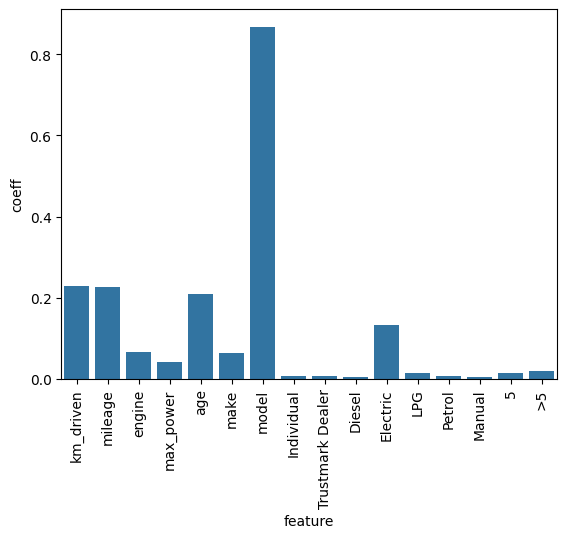

In [ ]:
import seaborn as sns

imp = pd.DataFrame(list(zip(X_test.columns,np.abs(model.coef_))),
                   columns=['feature', 'coeff'])
sns.barplot(x='feature', y='coeff', data=imp)
plt.xticks(rotation=90)

In [ ]:
X_test.columns[np.argmax(np.abs(model.coef_))]

'model'

In [ ]:
X_test.columns[np.argmin(np.abs(model.coef_))]

'Manual'